PROBLEM STATEMENT

Electricity consumption in households varies over time due to different usage patterns. Understanding these patterns and predicting future energy consumption is essential for efficient energy management and planning.

This project aims to analyze historical household power consumption data and forecast future energy usage using time-based patterns. By applying time series techniques and machine learning models, the project seeks to provide accurate predictions of energy consumption.

OBEJECTIVE

To analyze historical household energy consumption data
To preprocess and clean time series data
To convert raw data into a time-based format using resampling techniques
To perform feature engineering by extracting time-based features such as hour, day, and month
To build and train forecasting models (e.g., XGBoost)
To evaluate model performance using metrics like MAE and RMSE
To visualize actual vs predicted energy consumption

Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Load

In [18]:
df = pd.read_csv(
    r"C:\Users\HP\Downloads\archive (1)\household_power_consumption.txt",
    sep=';',
    low_memory=False
)

Check:

In [19]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


TO MAKE DATE AND TIME


In [20]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

ONLY REQUIRED COLOMN

In [21]:
df = df[['datetime', 'Global_active_power']]

DATA CLEANING


In [24]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

df = df.dropna()

FEATURE ENGINEERING

In [27]:
df['hour'] = df.index.hour
df['day'] = df.index.dayofweek
df['month'] = df.index.month

GRAPH VISUALIZATION

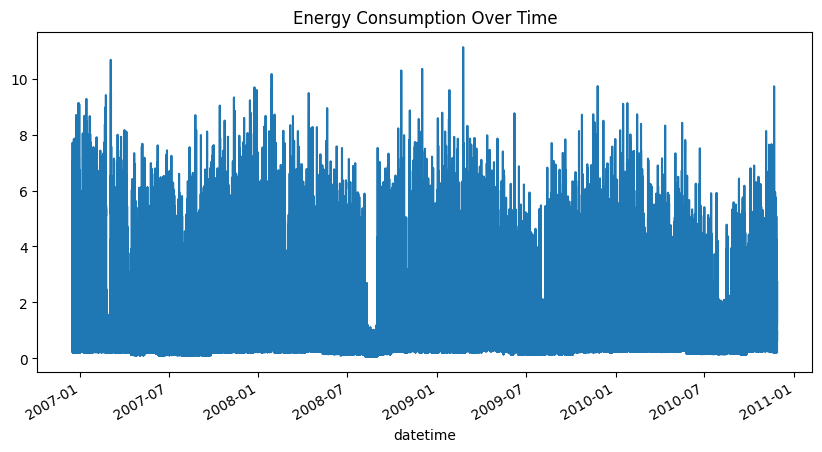

In [28]:
df['Global_active_power'].plot(figsize=(10,5))
plt.title("Energy Consumption Over Time")
plt.show()

TRAIN TEST SPLIT

In [29]:
train = df[:'2010-01-01']
test = df['2010-01-01':]

In [31]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.6 MB/s eta 0:01:02
   ---------------------------------------- 0.5/101.7 MB 1.6 MB/s eta 0:01:02
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:25
    --------------------------------------- 1.3/101.7 MB 1.0 MB/s eta 0:01:39
    --------------------------------------- 1.6/101.7 MB 1.1 MB/s eta 0:01:34
    --------------------------------------- 2.4/101.7 MB 1.3 MB/s eta 0:01:18
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:14
   - -------------------------------------- 3.1/101.7 MB 1.4 MB/s eta 0:01:10
   - ---------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


XGBOOST MODEL

In [32]:
from xgboost import XGBRegressor

features = ['hour', 'day', 'month']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

model = XGBRegressor()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

EVALUATION

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.5675015610046745
RMSE: 0.8145824172132193


FINAL GRAPH

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


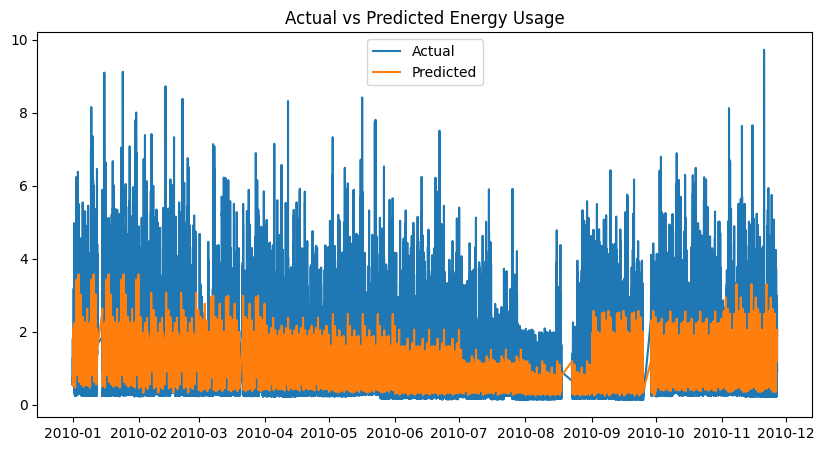

In [34]:
plt.figure(figsize=(10,5))

plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, predictions, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Energy Usage")

plt.show()